In [21]:
#installation
!pip install datasets

In [22]:
#import
from datasets import load_dataset

#dataset loading
pr_request = load_dataset("hao-li/AIDev", name="pull_request", split="train")

#dataframe
df_pr_request= pr_request.to_pandas()

#prints
print("Columns of pull_request:")
print(df_pr_request.columns.tolist())

Columns of pull_request:
['id', 'number', 'title', 'body', 'agent', 'user_id', 'user', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_id', 'repo_url', 'html_url']


In [23]:
#dataset loading
all_pr_request = load_dataset("hao-li/AIDev", name="all_pull_request", split="train")

#dataframe
df_all_pr_request= all_pr_request.to_pandas()

#prints
print("Columns of all pull request:")
print(df_all_pr_request.columns.tolist())

Columns of all pull request:
['id', 'number', 'title', 'user', 'user_id', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_url', 'repo_id', 'html_url', 'body', 'agent']


In [24]:
#dataset loading
pr_commit_details = load_dataset("hao-li/AIDev", name="pr_commit_details", split="train")

#dataframe
df_pr_commit_details= pr_commit_details.to_pandas()

#prints
print("Columns of pr commit details:")
print(df_pr_commit_details.columns.tolist())

Columns of pr commit details:
['sha', 'pr_id', 'author', 'committer', 'message', 'commit_stats_total', 'commit_stats_additions', 'commit_stats_deletions', 'filename', 'status', 'additions', 'deletions', 'changes', 'patch']


In [25]:
#imports
import re
import pandas as pd

#Rename required tables for easier approach
pull_request = df_pr_request
commit_details = df_pr_commit_details

#Merge Tables
merged = commit_details.merge(
    pull_request,
    left_on="pr_id",
    right_on="id",
    how="inner",
    suffixes=("_commit", "_pr")
)
print(f"Merged dataset size: {len(merged)} rows")

#Test Type classification and patterns 
TYPE_PATTERNS = {
    "unit": [
        r"\bunit\b", r"\bunittest\b",
        r"(^|/|\\)test(s)?(/|\\|$)",
        r"test_.*\.py$", r"_test\.(js|ts|java|go|py)$"
    ],
    "integration": [
        r"\bintegration\b", r"\bintegrat(e|ion)_test\b",
        r"(^|/)integration(s)?/"
    ],
    "e2e": [
        r"\be2e\b", r"end[-_ ]?to[-_ ]?end",
        r"/e2e/", r"/cypress/"
    ],
    "performance": [r"\bperf\b", r"\bperformance\b"],
    "regression": [r"\bregression\b"],
    "smoke": [r"\bsmoke\b"],
    "benchmark": [r"\bbenchmark\b", r"\bbench\b"],
}

def classify_test(file_path, commit_msg):
    text = f"{file_path} {commit_msg}".lower()

    for ttype, patterns in TYPE_PATTERNS.items():
        for p in patterns:
            if re.search(p, text):
                return ttype

    if ("test" in text or "spec" in text):
        return "other"

    return "unknown"


merged["test_type"] = merged.apply(
    lambda row: classify_test(row.get("file_path", ""), row.get("message", "")),
    axis=1
)

#Tests Per PR statistics
merged["has_test_file"] = merged["test_type"].apply(lambda x: x != "unknown")

pr_stats = merged.groupby("pr_id").agg(
    total_commits=("sha", "count"),  
    total_test_files=("has_test_file", "sum"),
    test_types=("test_type", lambda x: list(x[x != "unknown"]))
).reset_index()

pr_stats["contains_tests"] = pr_stats["total_test_files"] > 0
print("Completed per PR test statistics")

#Percentage of tests
total_agentic = len(pr_stats)
agentic_with_tests = pr_stats["contains_tests"].sum()
pct_with_tests = 100 * agentic_with_tests / total_agentic

print("\n======================")
print("GLOBAL TEST STATISTICS")
print("======================")
print(f"Total Agentic PRs: {total_agentic}")
print(f"Agentic PRs containing tests: {agentic_with_tests}")
print(f"Percentage: {pct_with_tests:.2f}%\n")

test_type_counts = merged["test_type"].value_counts().reset_index()
test_type_counts.columns = ["test_type", "count"]

print("Test Type Distribution:")
print(test_type_counts)


Merged dataset size: 711923 rows
Completed per PR test statistics

GLOBAL TEST STATISTICS
Total Agentic PRs: 33580
Agentic PRs containing tests: 8372
Percentage: 24.93%

Test Type Distribution:
     test_type   count
0      unknown  589632
1        other   97331
2  integration   12041
3         unit    4349
4  performance    3164
5    benchmark    2366
6          e2e    2036
7   regression     905
8        smoke      99


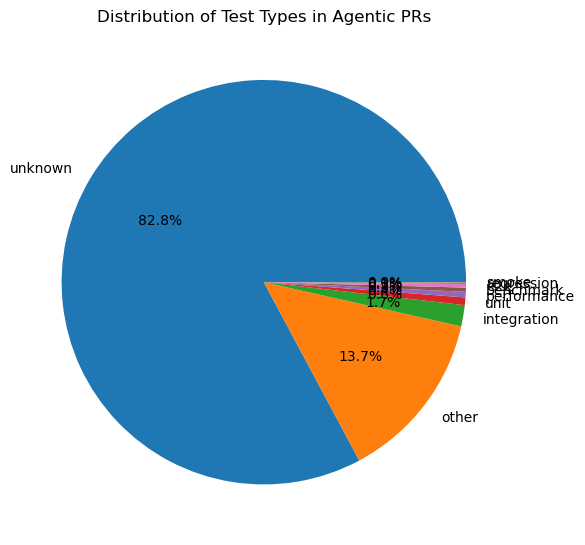

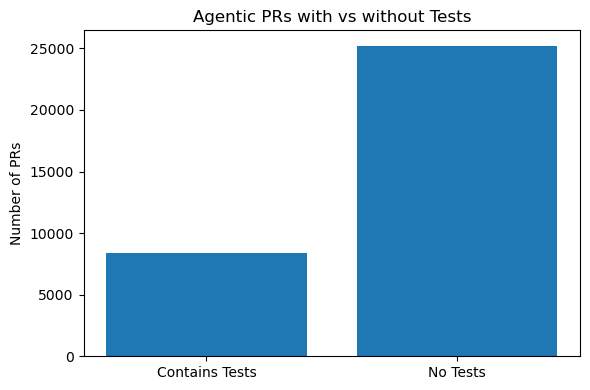

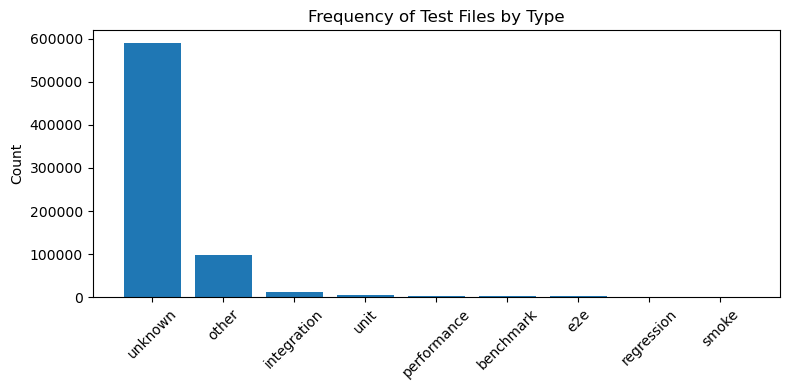

Completed


In [26]:
#imports
import matplotlib.pyplot as plt

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(test_type_counts["count"], labels=test_type_counts["test_type"], autopct="%1.1f%%")
plt.title("Distribution of Test Types in Agentic PRs")
plt.tight_layout()
plt.show()

# PRs with vs without tests
plt.figure(figsize=(6,4))
plt.bar(["Contains Tests", "No Tests"], [agentic_with_tests, total_agentic - agentic_with_tests])
plt.title("Agentic PRs with vs without Tests")
plt.ylabel("Number of PRs")
plt.tight_layout()
plt.show()

# Test file frequency
plt.figure(figsize=(8,4))
plt.bar(test_type_counts["test_type"], test_type_counts["count"])
plt.title("Frequency of Test Files by Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Completed")

In [27]:
#including patch of commit details
def classify_test(file_path, commit_msg, patch):
    text = f"{file_path} {commit_msg} {patch}".lower()

    for ttype, patterns in TYPE_PATTERNS.items():
        for p in patterns:
            if re.search(p, text):
                return ttype

    if ("test" in text or "spec" in text):
        return "other"

    return "unknown"

#Apply classification 
merged["test_type"] = merged.apply(
    lambda row: classify_test(
        row.get("file_path", ""),
        row.get("message", ""),
        row.get("patch", "")
    ),
    axis=1
)

#Tests Per PR statistics
merged["has_test_file"] = merged["test_type"].apply(lambda x: x != "unknown")

pr_stats = merged.groupby("pr_id").agg(
    total_commits=("sha", "count"),  
    total_test_files=("has_test_file", "sum"),
    test_types=("test_type", lambda x: list(x[x != "unknown"]))
).reset_index()

pr_stats["contains_tests"] = pr_stats["total_test_files"] > 0
print("Completed per PR test statistics")

#Percentage of tests
total_agentic = len(pr_stats)
agentic_with_tests = pr_stats["contains_tests"].sum()
pct_with_tests = 100 * agentic_with_tests / total_agentic

print("\n======================")
print("GLOBAL TEST STATISTICS")
print("======================")
print(f"Total Agentic PRs: {total_agentic}")
print(f"Agentic PRs containing tests: {agentic_with_tests}")
print(f"Percentage: {pct_with_tests:.2f}%\n")

test_type_counts = merged["test_type"].value_counts().reset_index()
test_type_counts.columns = ["test_type", "count"]

print("Test Type Distribution:")
print(test_type_counts)


Completed per PR test statistics

GLOBAL TEST STATISTICS
Total Agentic PRs: 33580
Agentic PRs containing tests: 23722
Percentage: 70.64%

Test Type Distribution:
     test_type   count
0      unknown  424826
1        other  214418
2         unit   28278
3  integration   26510
4  performance    8709
5    benchmark    3930
6          e2e    3637
7   regression    1260
8        smoke     355


In [28]:
# Test Classification Function
def classify_test(file_path, commit_msg, patch):
    text = f"{file_path} {commit_msg} {patch}".lower()

    for test_type, patterns in TYPE_PATTERNS.items():
        for pattern in patterns:
            if re.search(pattern, text):
                return test_type

    if "test" in text or "spec" in text:
        return "other"

    return "unknown"

# Apply Classification Row-wise
merged["test_type"] = merged.apply(
    lambda row: classify_test(
        row.get("file_path", ""),
        row.get("message", ""),
        row.get("patch", "")
    ),
    axis=1
)

In [46]:
import csv
# S1: PRs labeled as test-related
prs_with_tests = pr_stats[pr_stats["contains_tests"] == True]

# S2: PRs labeled as non-test
prs_without_tests = pr_stats[pr_stats["contains_tests"] == False]

# S3: PRs containing at least one "other" test type
prs_with_other_tests = pr_stats[
    pr_stats["test_types"].apply(lambda x: "other" in x)
]

# Stratified Sampling

# S1: PRs labeled as test-related
S1_sample = prs_with_tests.sample(
    n=min(200, len(prs_with_tests)),
    random_state=42
)

# S2: PRs labeled as non-test
S2_sample = prs_without_tests.sample(
    n=min(120, len(prs_without_tests)),
    random_state=42
)

# S3: PRs labeled as "Other" test type (subset of S1)
S3_sample = prs_with_other_tests.sample(
    n=min(80, len(prs_with_other_tests)),
    random_state=42
)

# Expand PR samples to file-level rows

def expand_pr_sample(pr_sample, label):
    expanded = merged[merged["pr_id"].isin(pr_sample["pr_id"])].copy()
    expanded["sampling_group"] = label
    return expanded[
        ["pr_id", "sha", "filename", "test_type", "message", "patch", "sampling_group"]
    ]

S1_files = expand_pr_sample(S1_sample, "S1_test_PRs")
S2_files = expand_pr_sample(S2_sample, "S2_non_test_PRs")
S3_files = expand_pr_sample(S3_sample, "S3_other_tests")

# Final manual validation dataset

manual_validation_dataset = pd.concat(
    [S1_files, S2_files, S3_files],
    ignore_index=True
)
# manual_validation_dataset.to_csv(
#     "stratified_pr_sample_for_manual_validation.tsv",
#     sep="\t",
#     index=False,
#     encoding="utf-8"
# )
manual_validation_dataset.to_csv(
    "stratified_pr_sample_for_manual_validation.csv",
    index=False,
    encoding="utf-8-sig",
    quoting=csv.QUOTE_ALL,
    escapechar="\\"
)

print(f"Manual validation dataset size: {len(manual_validation_dataset)} rows")

# ================================
# Unbiased stratified file-level sampling (400 rows)
# ================================

# TARGET_SAMPLES = {
#     "S1_test_PRs": 200,
#     "S2_non_test_PRs": 120,
#     "S3_other_tests": 80
# }

# final_400_samples = []

# for group, target_n in TARGET_SAMPLES.items():
#     subset = manual_validation_dataset[
#         manual_validation_dataset["sampling_group"] == group
#     ]

#     if len(subset) == 0:
#         continue

#     n = min(target_n, len(subset))

#     sampled_subset = subset.sample(
#         n=n,
#         random_state=42   # ensures reproducibility
#     )

#     final_400_samples.append(sampled_subset)

# final_annotation_sample = pd.concat(
#     final_400_samples,
#     ignore_index=True
# )

# ================================
# Reduce dominance of 'unknown' in final 400 samples
# ================================

TOTAL_TARGET = 100
MAX_UNKNOWN = 20    
RANDOM_SEED = 42

# Separate unknown and non-unknown
unknown_rows = manual_validation_dataset[
    manual_validation_dataset["test_type"] == "unknown"
]

known_rows = manual_validation_dataset[
    manual_validation_dataset["test_type"] != "unknown"
]

# Sample unknown rows (cap)
unknown_sample = unknown_rows.sample(
    n=min(MAX_UNKNOWN, len(unknown_rows)),
    random_state=RANDOM_SEED
)

# Sample remaining from known rows
remaining_needed = TOTAL_TARGET - len(unknown_sample)

known_sample = known_rows.sample(
    n=min(remaining_needed, len(known_rows)),
    random_state=RANDOM_SEED
)

# Combine and shuffle
final_annotation_sample = pd.concat(
    [unknown_sample, known_sample],
    ignore_index=True
).sample(
    frac=1,
    random_state=RANDOM_SEED
).reset_index(drop=True)

print(f"Final annotation sample size: {len(final_annotation_sample)}")
print("Unknown count:", (final_annotation_sample["test_type"] == "unknown").sum())


print(f"Final annotation sample size: {len(final_annotation_sample)}")

final_annotation_sample = final_annotation_sample.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# final_annotation_sample.to_csv(
#     "final_400_unbiased_annotation_sample.csv",
#     index=False
# )

# final_annotation_sample.to_excel(
#     "final_400_unbiased_annotation_sample.xlsx",
#     index=False
# )

annotation_file = final_annotation_sample.copy()
annotation_file["row_id"] = annotation_file.index

annotation_file = annotation_file.drop(
    columns=["test_type", "sampling_group"],
    errors="ignore"
)
annotation_file.to_csv(
    "manual_annotation_unbiased.csv",
    index=False
)
annotation_file.to_excel(
    "manual_annotation_unbiased.xlsx",
    index=False
)
print("Done")
print(f"Annotator's annotation sample size: {len(annotation_file)}")

Manual validation dataset size: 7693 rows
Final annotation sample size: 100
Unknown count: 20
Final annotation sample size: 100
Done
Annotator's annotation sample size: 100


In [57]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score

ann1 = pd.read_excel("annotator1.xlsx")
ann2 = pd.read_excel("annotator2.xlsx")
ann1 = ann1.rename(columns={
    "annotator_has_test": "has_test_a1",
    "annotator_test_type": "test_type_a1"
})

ann2 = ann2.rename(columns={
    "annotator_has_test": "has_test_a2",
    "annotator_test_type": "test_type_a2"
})
merged_ann = ann1.merge(
    ann2,
    on="row_id",
    how="inner"
)

print("Total labeled rows:", len(merged_ann))
merged_ann["has_test_a1"] = (
    merged_ann["has_test_a1"].astype(str).str.strip().str.upper()
)
merged_ann["has_test_a2"] = (
    merged_ann["has_test_a2"].astype(str).str.strip().str.upper()
)

merged_ann["test_type_a1"] = (
    merged_ann["test_type_a1"].astype(str).str.strip().str.lower()
)
merged_ann["test_type_a2"] = (
    merged_ann["test_type_a2"].astype(str).str.strip().str.lower()
)
kappa_has_test = cohen_kappa_score(
    merged_ann["has_test_a1"],
    merged_ann["has_test_a2"]
)

print(f"Cohen’s Kappa (has_test): {kappa_has_test:.3f}")
test_rows = merged_ann[
    (merged_ann["has_test_a1"] == "YES") &
    (merged_ann["has_test_a2"] == "YES")
]

kappa_test_type = cohen_kappa_score(
    test_rows["test_type_a1"],
    test_rows["test_type_a2"]
)

print(f"Cohen’s Kappa (test_type): {kappa_test_type:.3f}")
presence_disagreements = merged_ann[
    merged_ann["has_test_a1"] != merged_ann["has_test_a2"]
]

print("Presence disagreements:", len(presence_disagreements))
type_disagreements = test_rows[
    test_rows["test_type_a1"] != test_rows["test_type_a2"]
]

print("Type disagreements:", len(type_disagreements))
type_disagreements.to_excel("test_type_disagreements.xlsx", index=False)

print("Done")

Total labeled rows: 100
Cohen’s Kappa (has_test): 0.664
Cohen’s Kappa (test_type): 0.692
Presence disagreements: 16
Type disagreements: 10
Done


In [47]:
# Tests Per PR Statistics
merged["has_test_file"] = merged["test_type"].apply(lambda x: x != "unknown")

pr_stats = merged.groupby("pr_id").agg(
    total_commits=("sha", "count"),
    total_test_files=("has_test_file", "sum"),
    test_types=("test_type", lambda x: list(x[x != "unknown"]))
).reset_index()

pr_stats["contains_tests"] = pr_stats["total_test_files"] > 0

print("Completed per PR test statistics")

# Global Test Statistics
total_agentic = len(pr_stats)
agentic_with_tests = pr_stats["contains_tests"].sum()
pct_with_tests = 100 * agentic_with_tests / total_agentic

print("\n======================")
print("GLOBAL TEST STATISTICS")
print("======================")
print(f"Total Agentic PRs: {total_agentic}")
print(f"Agentic PRs containing tests: {agentic_with_tests}")
print(f"Percentage: {pct_with_tests:.2f}%\n")

# Test Type Distribution
test_type_counts = merged["test_type"].value_counts().reset_index()
test_type_counts.columns = ["test_type", "count"]

# Separate unknown from known test types
unknown_count = test_type_counts[test_type_counts["test_type"] == "unknown"]
known_test_type_counts = test_type_counts[test_type_counts["test_type"] != "unknown"]
unknown_count_value = merged["test_type"].value_counts().get("unknown", 0)


Completed per PR test statistics

GLOBAL TEST STATISTICS
Total Agentic PRs: 33580
Agentic PRs containing tests: 23722
Percentage: 70.64%



In [31]:
print("Test Type Distribution:")
print(known_test_type_counts)

print(f"\nNon-test file count: {unknown_count_value}")


Test Type Distribution:
     test_type   count
1        other  214418
2         unit   28278
3  integration   26510
4  performance    8709
5    benchmark    3930
6          e2e    3637
7   regression    1260
8        smoke     355

Non-test file count: 424826


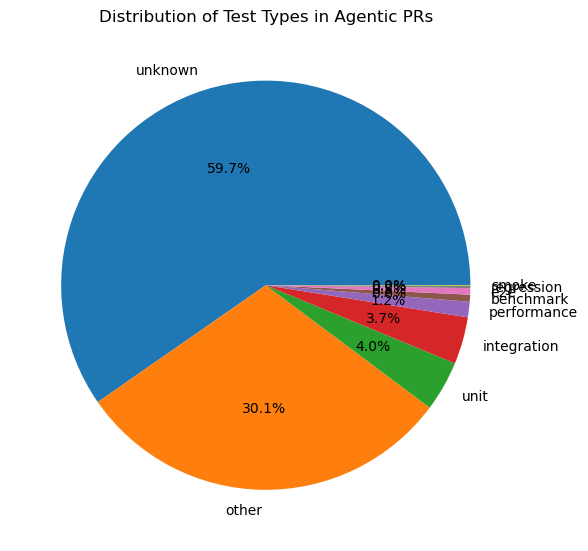

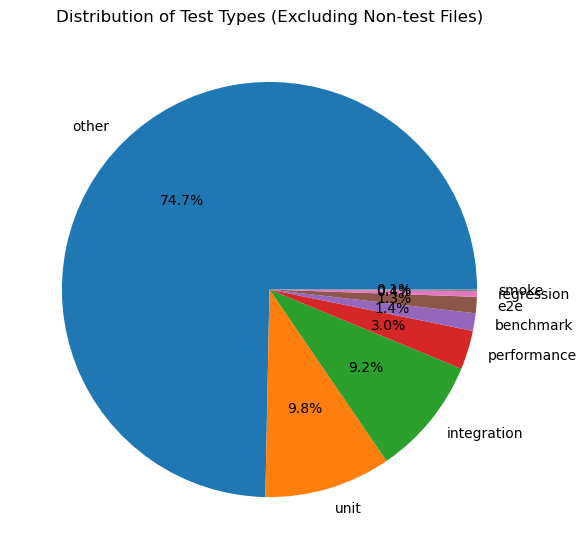

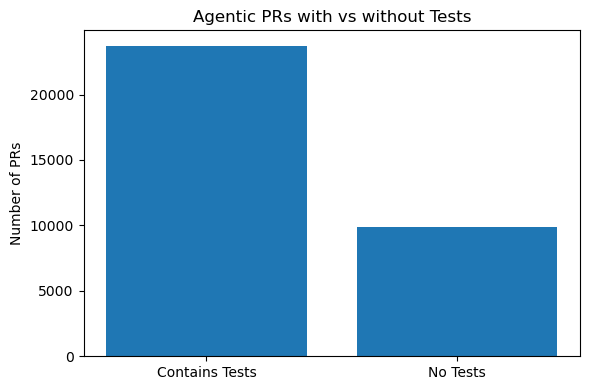

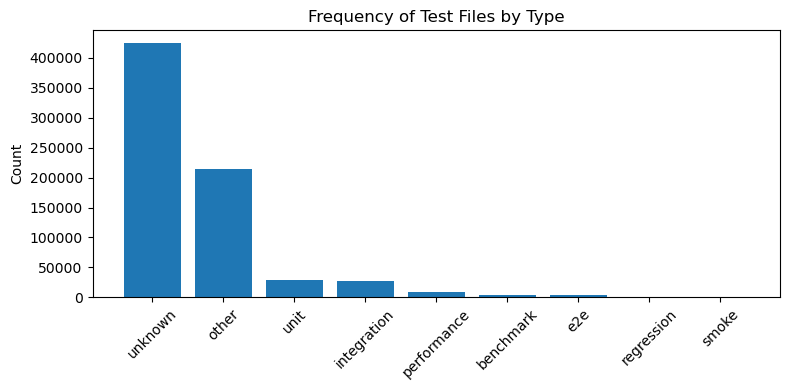

Completed


In [32]:
#imports
import matplotlib.pyplot as plt

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(test_type_counts["count"], labels=test_type_counts["test_type"], autopct="%1.1f%%")
plt.title("Distribution of Test Types in Agentic PRs")
plt.tight_layout()
plt.show()

pie_data = test_type_counts[test_type_counts["test_type"] != "unknown"]

# Pie chart (tests only)
plt.figure(figsize=(6, 6))
plt.pie(
    pie_data["count"],
    labels=pie_data["test_type"],
    autopct="%1.1f%%"
)
plt.title("Distribution of Test Types (Excluding Non-test Files)")
plt.tight_layout()
plt.show()

# PRs with vs without tests
plt.figure(figsize=(6,4))
plt.bar(["Contains Tests", "No Tests"], [agentic_with_tests, total_agentic - agentic_with_tests])
plt.title("Agentic PRs with vs without Tests")
plt.ylabel("Number of PRs")
plt.tight_layout()
plt.show()

# Test file frequency
plt.figure(figsize=(8,4))
plt.bar(test_type_counts["test_type"], test_type_counts["count"])
plt.title("Frequency of Test Files by Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Completed")